# 0. OSM candidate analysis notebook

Status: Non-final.

Scope: descriptive review of one OSM candidate CSV only.

Current project phase: External Data Acquisition + Reference Mapping + Source QA.

External data role: candidate enrichment only.

This notebook does not perform joins, modeling, training, feature importance, delivery conversion, source promotion, or business interpretation.

# 1. Basic file identity

In [66]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = Path(r"C:\Users\simon\food_prediction\raw_data\code_external_data\_external_data\osm_geofabrik_nrw_zip39_poi_source_snapshot_260531\osm_geofabrik_nrw_zip39_poi_including_bakeries_source_snapshot_260531.csv")

print("CSV path:", CSV_PATH)
print("CSV exists:", CSV_PATH.exists())
print("File size MB:", round(CSV_PATH.stat().st_size / (1024 * 1024), 3))
print("Last modified:", pd.to_datetime(CSV_PATH.stat().st_mtime, unit="s"))

CSV path: C:\Users\simon\food_prediction\raw_data\code_external_data\_external_data\osm_geofabrik_nrw_zip39_poi_source_snapshot_260531\osm_geofabrik_nrw_zip39_poi_including_bakeries_source_snapshot_260531.csv
CSV exists: True
File size MB: 23.34
Last modified: 2026-06-07 00:14:21.414362431


# 2. Load the CSV

In [67]:
df = pd.read_csv(CSV_PATH, dtype=str, low_memory=False)

print("Loaded rows:", len(df))
print("Loaded columns:", len(df.columns))
display(df.head(16))

Loaded rows: 84186
Loaded columns: 21


,feature_unique_id,osm_type,osm_id,geometry_type,representative_latitude,representative_longitude,coordinate_semantics,name,amenity,shop,...,leisure,office,craft,healthcare,public_transport,railway,highway,brand,operator,tags_json
0,n5286001,node,5286001,Point,50.8989773,6.3919101,POINT_COORDINATE_FROM_OSM_GEOMETRY,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""bicycle"":""yes"",""information"":""guidepost"",""to..."
1,n13332224,node,13332224,Point,50.7931367,6.0994165,POINT_COORDINATE_FROM_OSM_GEOMETRY,Sportpark Soers,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,NaN,NaN,NaN,NaN,"{""bus"":""yes"",""name"":""Sportpark Soers"",""note"":""..."
2,n21764353,node,21764353,Point,50.8095627,6.48236,POINT_COORDINATE_FROM_OSM_GEOMETRY,Düren,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,stop,NaN,NaN,DB InfraGO AG,"{""VRS:gemeinde"":""DÜREN"",""VRS:name"":""Düren Bf"",..."
3,n23660843,node,23660843,Point,50.6123474,6.3702654,POINT_COORDINATE_FROM_OSM_GEOMETRY,DJH Jugendherberge Simmerath-Rurberg für Natur...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Deutsches Jugendherbergswerk Landesverband Rhe...,"{""addr:city"":""Simmerath"",""addr:country"":""DE"",""..."
4,n26668634,node,26668634,Point,50.8136049,6.2520101,POINT_COORDINATE_FROM_OSM_GEOMETRY,Eschweiler Hbf,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,stop,NaN,NaN,NaN,"{""local_ref"":""1"",""name"":""Eschweiler Hbf"",""publ..."
5,n26668636,node,26668636,Point,50.8179591,6.3536202,POINT_COORDINATE_FROM_OSM_GEOMETRY,Langerwehe,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,stop,NaN,NaN,DB InfraGO AG,"{""local_ref"":""4"",""name"":""Langerwehe"",""operator..."
6,n27285580,node,27285580,Point,50.7688619,6.0564414,POINT_COORDINATE_FROM_OSM_GEOMETRY,Venskyhäuschen,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,NaN,NaN,NaN,NaN,"{""bus"":""yes"",""local_ref"":""H.1"",""name"":""Venskyh..."
7,n27285629,node,27285629,Point,50.7588243,6.0750632,POINT_COORDINATE_FROM_OSM_GEOMETRY,Kaiser-Friedrich-Park,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,NaN,NaN,NaN,NaN,"{""bus"":""yes"",""local_ref"":""H.2"",""name"":""Kaiser-..."
8,n27285638,node,27285638,Point,50.7613096,6.073734,POINT_COORDINATE_FROM_OSM_GEOMETRY,Goethestraße,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,NaN,NaN,NaN,NaN,"{""bus"":""yes"",""local_ref"":""H.3"",""name"":""Goethes..."
9,n27285769,node,27285769,Point,50.7522894,6.0973318,POINT_COORDINATE_FROM_OSM_GEOMETRY,Siegel,NaN,NaN,...,NaN,NaN,NaN,NaN,stop_position,NaN,NaN,NaN,NaN,"{""bus"":""yes"",""local_ref"":""H.4"",""name"":""Siegel""..."


# 3. Schema and column overview

In [68]:
columns = pd.DataFrame({
    "position": range(1, len(df.columns) + 1),
    "column": df.columns,
    "dtype_after_load": [str(df[col].dtype) for col in df.columns],
})

display(columns)

print("Column names:")
for col in df.columns:
    print("-", col)

,position,column,dtype_after_load
0,1,feature_unique_id,str
1,2,osm_type,str
2,3,osm_id,str
3,4,geometry_type,str
4,5,representative_latitude,str
5,6,representative_longitude,str
6,7,coordinate_semantics,str
7,8,name,str
8,9,amenity,str
9,10,shop,str


Column names:
- feature_unique_id
- osm_type
- osm_id
- geometry_type
- representative_latitude
- representative_longitude
- coordinate_semantics
- name
- amenity
- shop
- tourism
- leisure
- office
- craft
- healthcare
- public_transport
- railway
- highway
- brand
- operator
- tags_json


# 4. Row and column count checks

In [69]:
row_count = len(df)
column_count = len(df.columns)

count_checks = pd.DataFrame([
    {"item": "rows", "count": row_count},
    {"item": "columns", "count": column_count},
])

display(count_checks)

,item,count
0,rows,84186
1,columns,21


# 5. Missing-value analysis

,column,missing_count,missing_percent
16,railway,83911,99.67
13,craft,83519,99.21
12,office,82851,98.41
14,healthcare,82824,98.38
18,brand,81309,96.58
10,tourism,79444,94.37
17,highway,79049,93.90
9,shop,78341,93.06
19,operator,75125,89.24
15,public_transport,74119,88.04


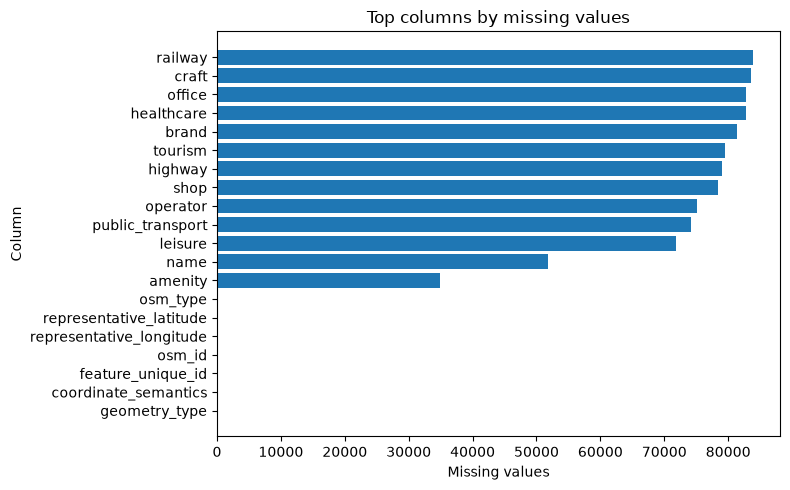

In [70]:
missing = pd.DataFrame({
    "column": df.columns,
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_percent": [round(df[col].isna().mean() * 100, 2) for col in df.columns],
}).sort_values(["missing_count", "column"], ascending=[False, True])

display(missing)

top_missing = missing.head(20).sort_values("missing_count", ascending=True)

plt.figure(figsize=(8, max(4, len(top_missing) * 0.25)))
plt.barh(top_missing["column"], top_missing["missing_count"])
plt.title("Top columns by missing values")
plt.xlabel("Missing values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# 6. Duplicate analysis

In [71]:
# Full-row, ID, and coordinate duplicate review.
# This is descriptive source QA only. It does not perform joins or source promotion.

full_duplicate_count = int(df.duplicated().sum())

print("Full duplicate rows:", full_duplicate_count)

if full_duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(20))
else:
    print("No full duplicate rows found by this simple check.")

duplicate_checks = []

if "feature_unique_id" in df.columns:
    feature_id_values = df["feature_unique_id"].dropna().astype(str)
    feature_id_duplicate_mask = feature_id_values.duplicated(keep=False)

    duplicate_checks.append({
        "check": "feature_unique_id",
        "non_empty_values": len(feature_id_values),
        "distinct_values": feature_id_values.nunique(),
        "rows_in_duplicate_values": int(feature_id_duplicate_mask.sum()),
        "duplicate_value_count": int(feature_id_values[feature_id_duplicate_mask].nunique()),
    })

if {"osm_type", "osm_id"}.issubset(df.columns):
    osm_key_values = (
        df["osm_type"].fillna("<missing>").astype(str)
        + "|"
        + df["osm_id"].fillna("<missing>").astype(str)
    )
    osm_key_duplicate_mask = osm_key_values.duplicated(keep=False)

    duplicate_checks.append({
        "check": "osm_type + osm_id",
        "non_empty_values": len(osm_key_values),
        "distinct_values": osm_key_values.nunique(),
        "rows_in_duplicate_values": int(osm_key_duplicate_mask.sum()),
        "duplicate_value_count": int(osm_key_values[osm_key_duplicate_mask].nunique()),
    })

lat_col = "representative_latitude"
lon_col = "representative_longitude"

if {lat_col, lon_col}.issubset(df.columns):
    coordinate_work = df.copy()
    coordinate_work["_lat_num"] = pd.to_numeric(coordinate_work[lat_col], errors="coerce")
    coordinate_work["_lon_num"] = pd.to_numeric(coordinate_work[lon_col], errors="coerce")
    coordinate_work = coordinate_work.dropna(subset=["_lat_num", "_lon_num"]).copy()

    coordinate_work["_coordinate_pair"] = (
        coordinate_work["_lat_num"].round(7).astype(str)
        + "|"
        + coordinate_work["_lon_num"].round(7).astype(str)
    )

    coordinate_pair_counts = coordinate_work["_coordinate_pair"].value_counts()
    repeated_coordinate_pairs = coordinate_pair_counts[coordinate_pair_counts > 1]

    duplicate_checks.append({
        "check": "representative latitude + longitude",
        "non_empty_values": len(coordinate_work),
        "distinct_values": coordinate_work["_coordinate_pair"].nunique(),
        "rows_in_duplicate_values": int(repeated_coordinate_pairs.sum()),
        "duplicate_value_count": int(len(repeated_coordinate_pairs)),
    })

duplicate_checks_df = pd.DataFrame(duplicate_checks)
display(duplicate_checks_df)

if {lat_col, lon_col}.issubset(df.columns) and len(repeated_coordinate_pairs) > 0:
    repeated_coordinates = coordinate_work[
        coordinate_work["_coordinate_pair"].isin(repeated_coordinate_pairs.index)
    ].copy()

    def sample_values(series, limit=5):
        values = series.dropna().astype(str).drop_duplicates().head(limit).tolist()
        return "; ".join(values)

    top_repeated_coordinates = (
        repeated_coordinates
        .groupby("_coordinate_pair")
        .agg(
            row_count=("feature_unique_id", "size"),
            distinct_feature_ids=("feature_unique_id", "nunique"),
            distinct_osm_ids=("osm_id", "nunique"),
            distinct_names=("name", lambda s: s.dropna().astype(str).nunique()),
            sample_names=("name", sample_values),
        )
        .sort_values(["row_count", "distinct_feature_ids"], ascending=[False, False])
        .head(20)
        .reset_index()
    )

    split_coordinates = top_repeated_coordinates["_coordinate_pair"].str.split("|", expand=True)
    top_repeated_coordinates.insert(1, "representative_latitude_rounded", split_coordinates[0])
    top_repeated_coordinates.insert(2, "representative_longitude_rounded", split_coordinates[1])

    display(top_repeated_coordinates)

if "coordinate_semantics" in df.columns:
    coordinate_semantics_counts = (
        df["coordinate_semantics"]
        .fillna("<missing>")
        .astype(str)
        .value_counts()
        .reset_index(name="count")
        .rename(columns={"index": "coordinate_semantics"})
    )

    display(coordinate_semantics_counts)


Full duplicate rows: 0
No full duplicate rows found by this simple check.


,check,non_empty_values,distinct_values,rows_in_duplicate_values,duplicate_value_count
0,feature_unique_id,84186,84186,0,0
1,osm_type + osm_id,84186,63164,42044,21022
2,representative latitude + longitude,84186,63154,42052,21020


,_coordinate_pair,representative_latitude_rounded,representative_longitude_rounded,row_count,distinct_feature_ids,distinct_osm_ids,distinct_names,sample_names
0,50.7794197|6.0745124,50.7794197,6.0745124,10,10,5,0,
1,50.7418514|6.1592646,50.7418514,6.1592646,4,4,2,0,
2,50.7892807|6.0651006,50.7892807,6.0651006,4,4,2,1,Lambertz Werksverkauf
3,50.4992166|6.2256449,50.4992166,6.2256449,2,2,1,0,
4,50.5032906|6.3262266,50.5032906,6.3262266,2,2,1,1,Wahlerscheid
5,50.5040093|6.324734,50.5040093,6.324734,2,2,1,0,
6,50.505103|6.2456779,50.505103,6.2456779,2,2,1,1,Gut Heistert
7,50.5084039|6.2182596,50.5084039,6.2182596,2,2,1,1,Breitenbachtal
8,50.5109742|6.2366982,50.5109742,6.2366982,2,2,1,0,
9,50.5112306|6.2367084,50.5112306,6.2367084,2,2,1,0,


,coordinate_semantics,count
0,GEOMETRY_BOUNDING_BOX_CENTER_APPROXIMATE,42423
1,POINT_COORDINATE_FROM_OSM_GEOMETRY,41763


# 7. AGS and postcode-like fields

Direct AGS/municipality/postcode-like columns: []
Note: tags_json is not treated as a direct mapping column.
Mapping-like keys inside tags_json:


,tag_key,rows_with_key
1,addr:postcode,12948
0,VRS:gemeinde,174
2,postal_code,77
3,object:postcode,25
4,post:postcode,5
6,contact:postcode,2
5,addr:zip,1


,metric,count
0,rows_total,84186
1,rows_with_review_postcode_candidate,13054
2,rows_with_5_digit_review_postcode_candidate,13053
3,rows_with_non_5_digit_review_postcode_candidate,1
4,distinct_5_digit_review_postcodes,41


Top review postcode candidates:


,review_postcode_candidate,rows
0,52062,1221
1,52525,688
2,41812,560
3,52428,555
4,52152,542
5,52249,528
6,52070,498
7,52064,476
8,52146,460
9,52066,457


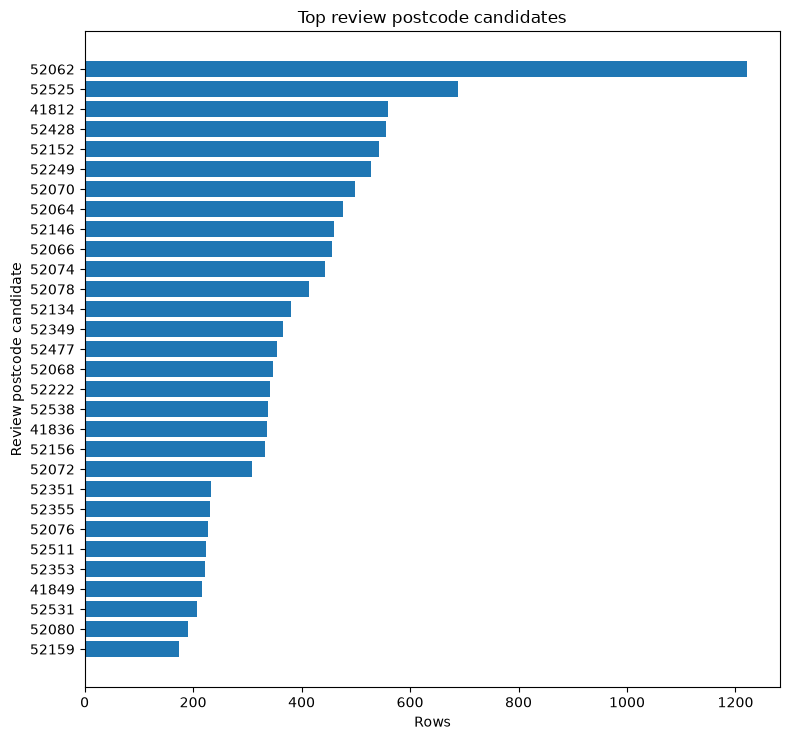

Non-5-digit review postcode examples:


,review_postcode_candidate,rows
0,4720,1



PLZ-level category review for amenity:


,review_postcode_candidate,amenity,rows
112,52062,restaurant,118
599,52249,kindergarten,72
946,52525,doctors,65
963,52525,restaurant,55
22,41812,place_of_worship,54
1008,52538,place_of_worship,50
94,52062,fast_food,48
397,52134,kindergarten,47
81,52062,brothel,46
812,52428,kindergarten,45


,amenity,rows
0,kindergarten,903
1,restaurant,796
2,place_of_worship,621
3,school,543
4,doctors,466
5,fast_food,314
6,social_facility,310
7,community_centre,251
8,fire_station,236
9,cafe,228


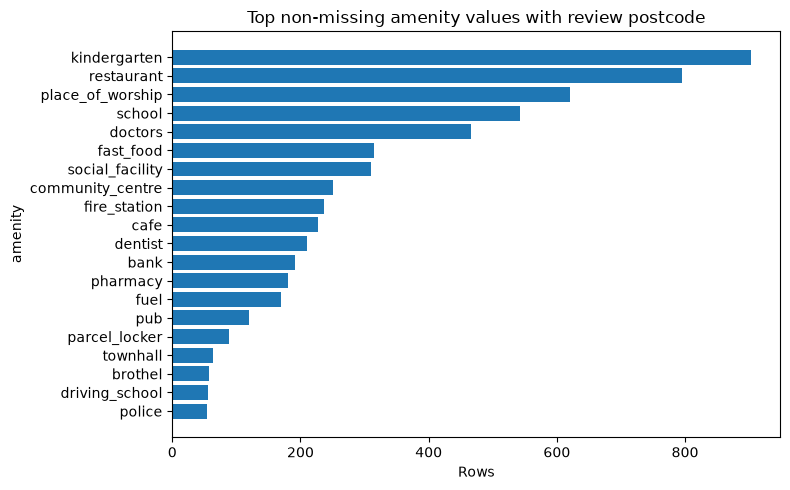


PLZ-level category review for shop:


,review_postcode_candidate,shop,rows
116,52062,clothes,63
138,52062,hairdresser,35
146,52062,jewelry,28
835,52249,supermarket,26
883,52349,supermarket,25
1197,52525,supermarket,25
468,52078,car_repair,24
490,52078,supermarket,23
559,52134,supermarket,23
731,52222,car_repair,23


,shop,rows
0,supermarket,507
1,car_repair,250
2,bakery,237
3,car,237
4,hairdresser,223
5,clothes,220
6,convenience,122
7,bicycle,97
8,kiosk,92
9,chemist,79


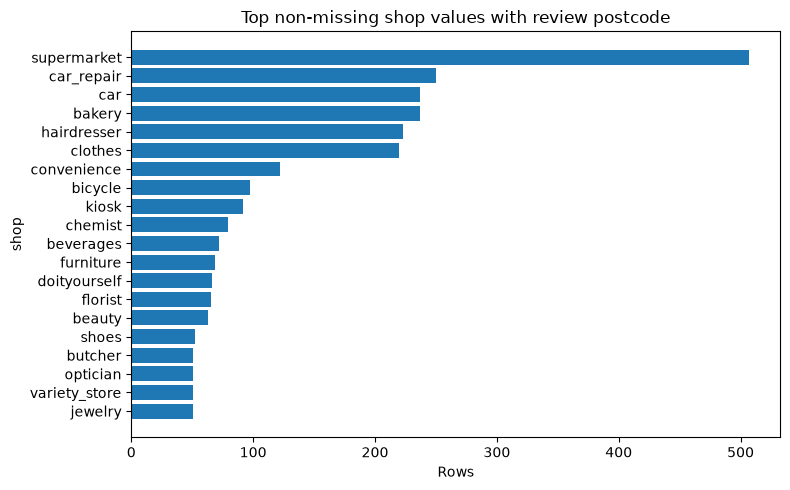


PLZ-level category review for tourism:


,review_postcode_candidate,tourism,rows
65,52152,hotel,30
63,52152,guest_house,29
22,52062,hotel,28
77,52156,hotel,27
147,52525,apartment,26
28,52064,hotel,21
160,52538,guest_house,19
13,41849,apartment,18
37,52070,hotel,18
149,52525,chalet,16


,tourism,rows
0,hotel,257
1,apartment,110
2,guest_house,106
3,museum,74
4,chalet,67
5,information,36
6,attraction,26
7,hostel,23
8,camp_site,14
9,gallery,13


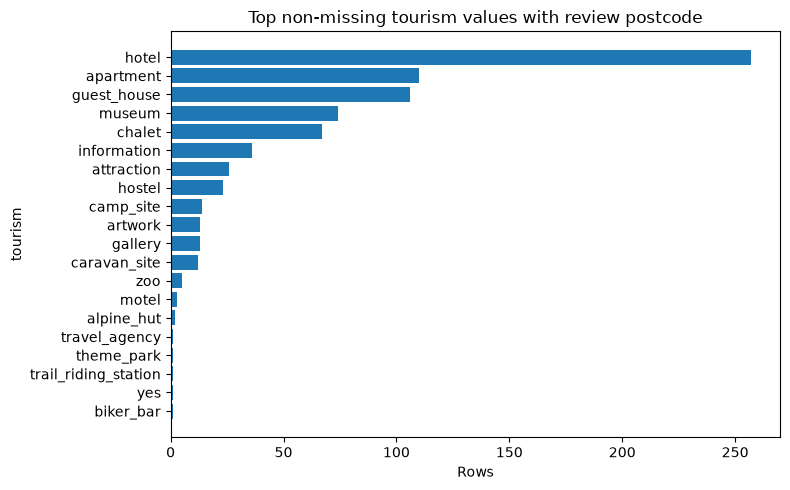


PLZ-level category review for leisure:


,review_postcode_candidate,leisure,rows
5,41812,sports_centre,12
133,52511,sports_centre,12
146,52538,pitch,12
74,52146,sports_centre,10
55,52074,sports_centre,9
78,52152,sports_centre,8
138,52525,sports_centre,8
22,52062,sports_centre,7
94,52249,sports_centre,7
124,52441,sports_centre,7


,leisure,rows
0,sports_centre,163
1,fitness_centre,64
2,pitch,35
3,sports_hall,29
4,dance,25
5,horse_riding,20
6,park,14
7,adult_gaming_centre,9
8,playground,9
9,water_park,8


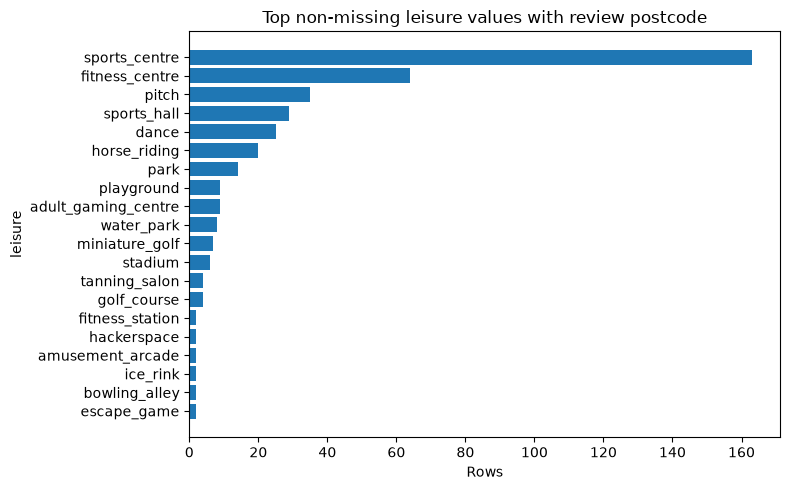

Review note: PLZ-level fields are descriptive candidates only. They are not treated as mapping-safe join keys.


In [72]:
import json
import re
from collections import Counter

mapping_column_pattern = re.compile(
    r"(^|[_:\-])(ags|gemeindeschluessel|gemeindeschlüssel|gemeinde|municipality|plz|postcode|postal_code|zip)([_:\-]|$)",
    re.IGNORECASE,
)

mapping_tag_key_pattern = re.compile(
    r"(^|[_:\-])(ags|gemeindeschluessel|gemeindeschlüssel|gemeinde|municipality|plz|postcode|postal_code|zip)([_:\-]|$)",
    re.IGNORECASE,
)

excluded_mapping_columns = {"tags_json"}

direct_mapping_columns = [
    col for col in df.columns
    if col not in excluded_mapping_columns and mapping_column_pattern.search(col)
]

print("Direct AGS/municipality/postcode-like columns:", direct_mapping_columns)
print("Note: tags_json is not treated as a direct mapping column.")

def parse_tag_payload(value):
    if pd.isna(value):
        return {}
    try:
        parsed = json.loads(value)
        if isinstance(parsed, dict):
            return parsed
    except Exception:
        return {}
    return {}

tag_key_counts = Counter()

if "tags_json" in df.columns:
    for raw_value in df["tags_json"]:
        tag_key_counts.update(parse_tag_payload(raw_value).keys())

mapping_tag_keys = [
    key for key, count in tag_key_counts.items()
    if mapping_tag_key_pattern.search(str(key))
]

mapping_tag_summary = pd.DataFrame(
    [{"tag_key": key, "rows_with_key": tag_key_counts[key]} for key in mapping_tag_keys]
).sort_values(["rows_with_key", "tag_key"], ascending=[False, True])

print("Mapping-like keys inside tags_json:")

if len(mapping_tag_summary) == 0:
    print("No mapping-like keys found inside tags_json by this keyword check.")
else:
    display(mapping_tag_summary)

postcode_priority_keys = [
    "addr:postcode",
    "postal_code",
    "object:postcode",
    "post:postcode",
    "contact:postcode",
    "addr:zip",
]

german_postcode_pattern = re.compile(r"^\d{5}$")

def extract_review_postcode(raw_value):
    tags = parse_tag_payload(raw_value)
    for key in postcode_priority_keys:
        value = tags.get(key)
        if value is None:
            continue
        value = str(value).strip()
        if value:
            return value
    return pd.NA

if "tags_json" in df.columns:
    review = df.copy()
    review["review_postcode_candidate"] = review["tags_json"].apply(extract_review_postcode)
    review["review_postcode_is_5_digit"] = review["review_postcode_candidate"].astype("string").str.match(german_postcode_pattern, na=False)

    postcode_values = review["review_postcode_candidate"].dropna().astype(str)
    valid_postcode_values = review.loc[review["review_postcode_is_5_digit"], "review_postcode_candidate"].astype(str)
    invalid_postcode_values = review.loc[
        review["review_postcode_candidate"].notna() & ~review["review_postcode_is_5_digit"],
        "review_postcode_candidate"
    ].astype(str)

    postcode_summary = pd.DataFrame([
        {
            "metric": "rows_total",
            "count": len(review),
        },
        {
            "metric": "rows_with_review_postcode_candidate",
            "count": len(postcode_values),
        },
        {
            "metric": "rows_with_5_digit_review_postcode_candidate",
            "count": len(valid_postcode_values),
        },
        {
            "metric": "rows_with_non_5_digit_review_postcode_candidate",
            "count": len(invalid_postcode_values),
        },
        {
            "metric": "distinct_5_digit_review_postcodes",
            "count": valid_postcode_values.nunique(),
        },
    ])

    display(postcode_summary)

    print("Top review postcode candidates:")
    top_postcodes = (
        valid_postcode_values
        .value_counts()
        .head(30)
        .reset_index(name="rows")
        .rename(columns={"index": "review_postcode_candidate"})
    )
    display(top_postcodes)

    if len(top_postcodes) > 0:
        plot_top_postcodes = top_postcodes.sort_values("rows", ascending=True)

        plt.figure(figsize=(8, max(4, len(plot_top_postcodes) * 0.25)))
        plt.barh(plot_top_postcodes["review_postcode_candidate"].astype(str), plot_top_postcodes["rows"])
        plt.title("Top review postcode candidates")
        plt.xlabel("Rows")
        plt.ylabel("Review postcode candidate")
        plt.tight_layout()
        plt.show()

    if len(invalid_postcode_values) > 0:
        print("Non-5-digit review postcode examples:")
        display(
            invalid_postcode_values
            .value_counts()
            .head(20)
            .reset_index(name="rows")
            .rename(columns={"index": "review_postcode_candidate"})
        )
    else:
        print("No non-5-digit review postcode candidates found.")

    category_columns_for_plz_review = ["amenity", "shop", "tourism", "leisure"]

    for category_col in category_columns_for_plz_review:
        if category_col not in review.columns:
            continue

        category_work = review[
            review["review_postcode_is_5_digit"] &
            review[category_col].notna()
        ].copy()

        print(f"\nPLZ-level category review for {category_col}:")

        if len(category_work) == 0:
            print(f"No rows with both 5-digit review postcode and non-missing {category_col}.")
            continue

        category_counts = (
            category_work
            .groupby(["review_postcode_candidate", category_col])
            .size()
            .reset_index(name="rows")
            .sort_values(["rows", "review_postcode_candidate", category_col], ascending=[False, True, True])
            .head(30)
        )

        display(category_counts)

        top_category_values = (
            category_work[category_col]
            .astype(str)
            .value_counts()
            .head(20)
            .reset_index(name="rows")
            .rename(columns={"index": category_col})
        )

        display(top_category_values)

        plot_category_values = top_category_values.sort_values("rows", ascending=True)

        plt.figure(figsize=(8, max(4, len(plot_category_values) * 0.25)))
        plt.barh(plot_category_values[category_col].astype(str), plot_category_values["rows"])
        plt.title(f"Top non-missing {category_col} values with review postcode")
        plt.xlabel("Rows")
        plt.ylabel(category_col)
        plt.tight_layout()
        plt.show()

print("Review note: PLZ-level fields are descriptive candidates only. They are not treated as mapping-safe join keys.")


# 8. POI category review

Category candidate columns: ['osm_type', 'geometry_type', 'amenity', 'shop', 'tourism', 'leisure']

Column: osm_type


,count,count
0,way,42423
1,node,41763


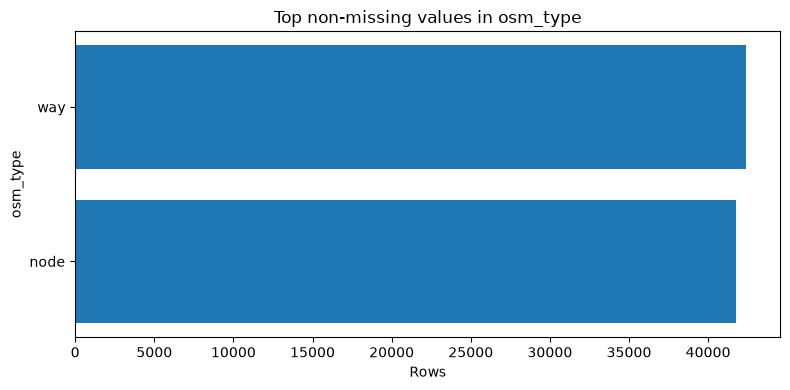


Column: geometry_type


,count,count
0,Point,41763
1,LineString,21269
2,MultiPolygon,21154


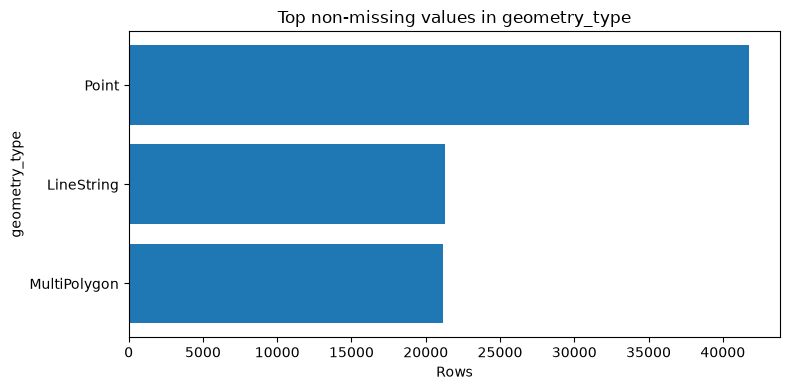


Column: amenity


,count,count
0,<missing>,34846
1,parking,14603
2,bench,7689
3,parking_space,4627
4,waste_basket,3077
5,bicycle_parking,2469
6,place_of_worship,1537
7,recycling,1113
8,restaurant,1093
9,kindergarten,1046


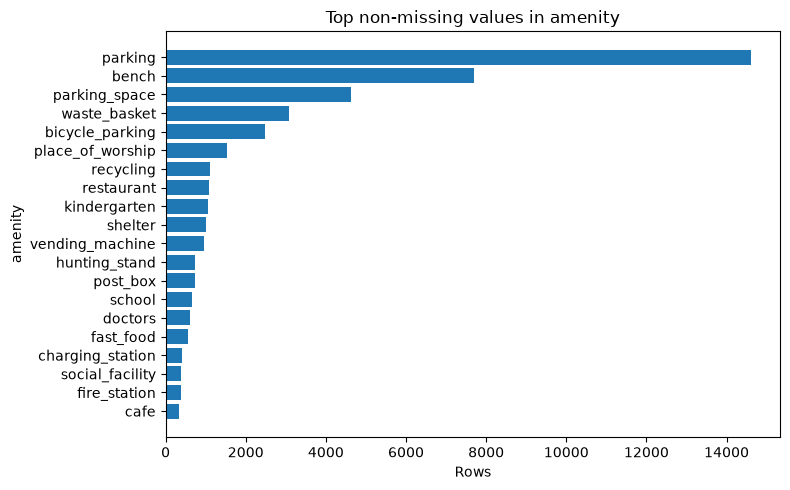


Column: shop


,count,count
0,<missing>,78341
1,supermarket,568
2,hairdresser,422
3,clothes,405
4,bakery,364
5,car_repair,352
6,car,323
7,kiosk,220
8,convenience,167
9,florist,112


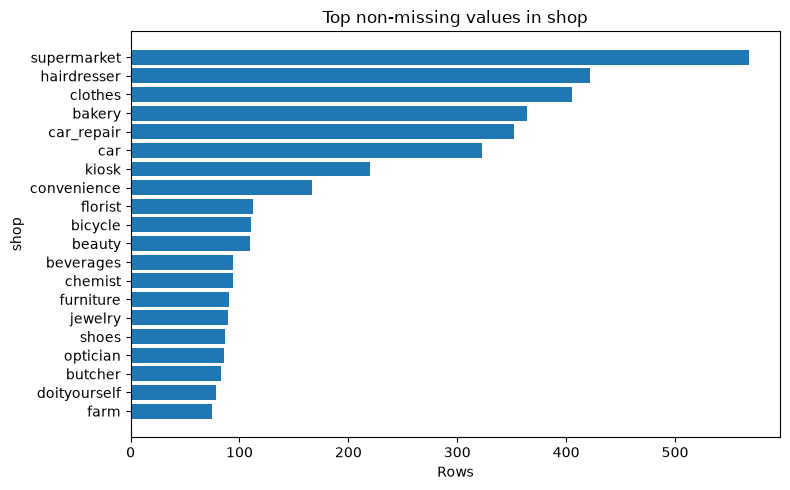


Column: tourism


,count,count
0,<missing>,79444
1,information,2445
2,attraction,350
3,picnic_site,321
4,hotel,303
5,viewpoint,287
6,artwork,277
7,camp_pitch,149
8,apartment,129
9,guest_house,116


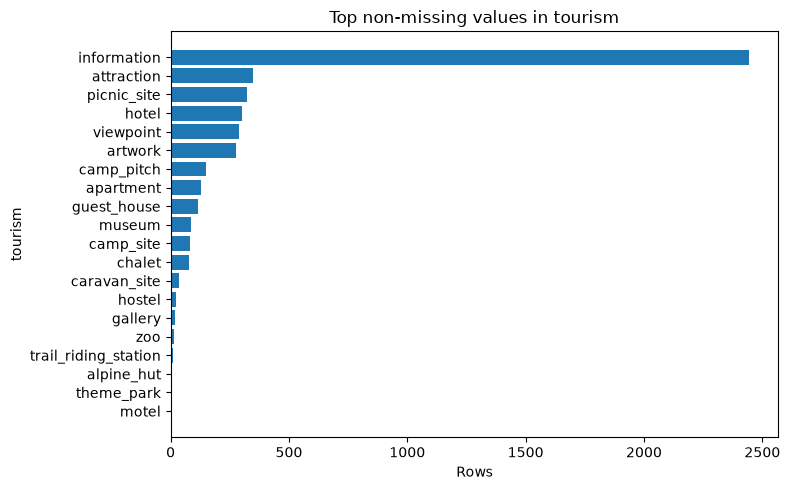


Column: leisure


,count,count
0,<missing>,71903
1,pitch,4078
2,playground,2438
3,garden,1762
4,sports_centre,775
5,park,683
6,picnic_table,492
7,swimming_pool,345
8,nature_reserve,324
9,outdoor_seating,229


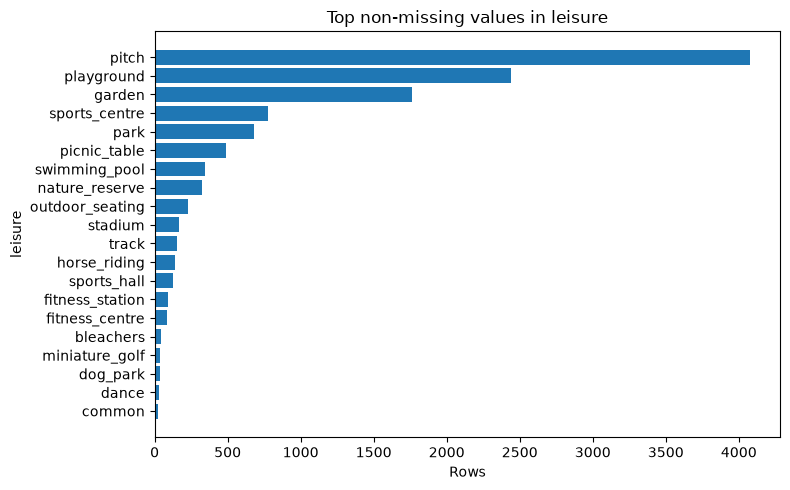

In [73]:
category_candidates = [
    col for col in df.columns
    if any(token in col.lower() for token in ["amenity", "shop", "tourism", "leisure", "category", "type"])
]

print("Category candidate columns:", category_candidates)

for col in category_candidates:
    counts = df[col].fillna("<missing>").astype(str).value_counts().head(25)

    print("\nColumn:", col)
    display(counts.reset_index().rename(columns={"index": col, col: "count"}))

    plot_counts = counts[counts.index != "<missing>"].head(20)

    if len(plot_counts) == 0:
        print(f"No non-missing values available for chart: {col}")
        continue

    plot_counts = plot_counts.sort_values(ascending=True)

    plt.figure(figsize=(8, max(4, len(plot_counts) * 0.25)))
    plt.barh(plot_counts.index.astype(str), plot_counts.values)
    plt.title(f"Top non-missing values in {col}")
    plt.xlabel("Rows")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# 9. Coordinate review

Coordinate candidate columns: ['representative_latitude', 'representative_longitude', 'coordinate_semantics']


,column,numeric_count,min,max,distinct_numeric_values
0,representative_latitude,84186,50.498971,51.147054,62528


,column,numeric_count,min,max,distinct_numeric_values
0,representative_longitude,84186,5.866319,6.591436,62712


,column,numeric_count,min,max,distinct_numeric_values
0,coordinate_semantics,0,NaN,NaN,0


Rows usable for simple coordinate plot: 84186


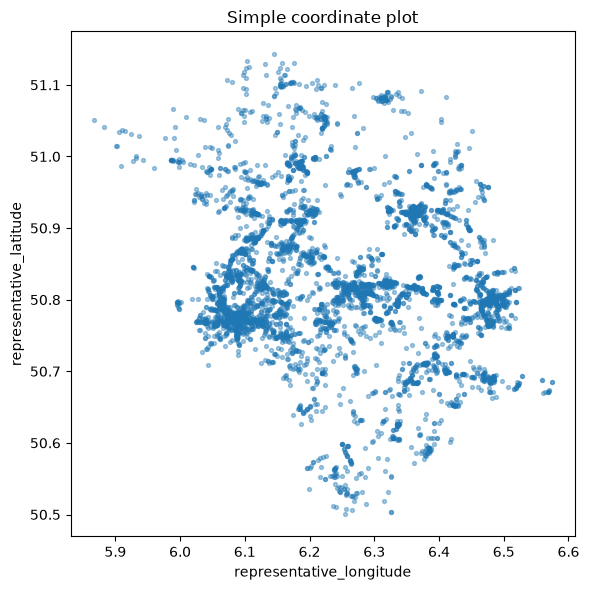

In [74]:
coord_candidates = [
    col for col in df.columns
    if col.lower() in ["lat", "latitude", "lon", "lng", "longitude", "x", "y"]
    or any(token in col.lower() for token in ["lat", "lon", "lng", "coord"])
]

print("Coordinate candidate columns:", coord_candidates)

for col in coord_candidates:
    numeric = pd.to_numeric(df[col], errors="coerce")
    result = pd.DataFrame([{
        "column": col,
        "numeric_count": numeric.notna().sum(),
        "min": numeric.min(),
        "max": numeric.max(),
        "distinct_numeric_values": numeric.nunique(dropna=True),
    }])
    display(result)

lat_cols = [col for col in coord_candidates if "lat" in col.lower()]
lon_cols = [col for col in coord_candidates if "lon" in col.lower() or "lng" in col.lower()]

if lat_cols and lon_cols:
    lat_col = lat_cols[0]
    lon_col = lon_cols[0]
    plot_data = pd.DataFrame({
        "lat": pd.to_numeric(df[lat_col], errors="coerce"),
        "lon": pd.to_numeric(df[lon_col], errors="coerce"),
    }).dropna()

    print("Rows usable for simple coordinate plot:", len(plot_data))

    if len(plot_data) > 0:
        plot_data = plot_data.head(5000)
        plt.figure(figsize=(6, 6))
        plt.scatter(plot_data["lon"], plot_data["lat"], alpha=0.4, s=8)
        plt.title("Simple coordinate plot")
        plt.xlabel(lon_col)
        plt.ylabel(lat_col)
        plt.tight_layout()
        plt.show()
else:
    print("No clear latitude/longitude pair found by this simple column-name check.")

# 10. Review notes

Status: Non-final.

This notebook is a descriptive source-QA review for one OSM candidate CSV.

Main review level:
- The relevant descriptive review level is PLZ/postcode candidate level.
- The review postcode field is named `review_postcode_candidate`.
- This field is derived from postcode-like OSM tag keys inside `tags_json`.
- It is a review candidate only, not a verified join key.

Coordinate boundary:
- Latitude and longitude are used only for basic technical plausibility and geometry-semantics review.
- Exact coordinates are not the analysis level for this notebook.
- Approximate geometry centers must not be interpreted as precise POI or store locations.

Mapping boundary:
- PLZ/postcode values are not treated as one-to-one municipality identifiers.
- Multi-municipality ZIP allocation is not resolved in this notebook.
- AGS, municipality identity, NRW boundary consistency, and join direction remain TODO-VERIFY.

Source and delivery boundary:
- Source identity, source URL, access method, access date, license or usage terms, temporal semantics, update logic, and source limitations remain TODO-VERIFY unless documented separately.
- This notebook does not establish delivery readiness, redistribution suitability, source promotion, downstream eligibility, leakage safety, mapping safety, predictive value, operational value, or business value.

Allowed interpretation:
- Use the outputs as descriptive candidate-source QA only.
- Use row counts, missing values, duplicate indicators, category counts, and PLZ-level category counts as review evidence.
- Do not use availability alone as evidence for quality, join safety, causal availability, or forecast usefulness.
